In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
%cd "/content/drive/MyDrive/Road_to_Data_Sci/Deep_Learning/Pytorch_Learning/Brain_Tumor_Classification"

/content/drive/MyDrive/Road_to_Data_Sci/Deep_Learning/Pytorch_Learning/Brain_Tumor_Classification


In [3]:
!pip install optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
from torch.cuda.amp import GradScaler, autocast
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import optuna
import shutil
import os
import time
from tqdm.auto import tqdm
import torch.nn.functional as F

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 10.1 MB/s eta 0:00:00


# **Data Collection**

In [4]:
train_dir ='/content/drive/MyDrive/Road_to_Data_Sci/Deep_Learning/Pytorch_Learning/Brain_Tumor_Classification/Training'

In [5]:
stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

In [7]:
dataset =datasets.ImageFolder(root=train_dir, transform=train_transforms)
train_loader =DataLoader(dataset, batch_size=32, shuffle=True)
print(f"พบรูปทั้งหมด: {len(dataset)} รูป")
print(f"พบ Class: {len(dataset.classes)}")

พบรูปทั้งหมด: 5600 รูป
พบ Class: 4


# **Model Building**

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"ตอนนี้กำลังใช้ {device}")

ตอนนี้กำลังใช้ cuda


In [9]:
class AdvancedResNetClassifier(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.3):
        super().__init__()
        self.backbone = models.resnet50(weights='DEFAULT')

        input_dim = self.backbone.fc.in_features

        self.backbone.fc = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

In [10]:
class EarlyStopping:
    def __init__(self, patience=3, delta=0, verbose=False, path='checkpoint.pth'):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf

    def __call__(self, val_loss, model, path=None):
        if path: self.path = path
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [11]:
def objective(trial):
    # ==========================
    # 🎯 1. Optuna Hyperparameters
    # ==========================
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True) # ResNet ชอบ LR เยอะกว่า NLP นิดนึง
    batch_size = trial.suggest_categorical("batch_size", [16, 32])
    dropout = trial.suggest_float("dropout", 0.2, 0.5)
    weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-2)

    # Gradient Accumulation
    accum_steps = 2 if batch_size == 16 else 1

    print(f"\n🚀 Trial {trial.number}: LR={lr:.5f}, BS={batch_size}, Drop={dropout:.2f}")

    # ==========================
    # 🔄 2. K-Fold Setup
    # ==========================
    N_FOLDS = 3
    N_EPOCHS = 4

    all_labels = dataset.targets

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_accuracies = []

    # Fold Loop
    for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(all_labels)), all_labels)):
        print(f"  📂 Fold {fold+1}/{N_FOLDS}")

        # Prepare Data
        train_sub = Subset(dataset, train_idx)
        val_sub = Subset(dataset, val_idx)

        train_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True, num_workers=2)
        val_loader = DataLoader(val_sub, batch_size=batch_size, shuffle=False, num_workers=2)

        # ⚠️ แก้จุดที่ 3: เรียก Model ของ ResNet
        model = AdvancedResNetClassifier(num_classes=4, dropout_rate=dropout).to(device)

        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        criterion = nn.CrossEntropyLoss()
        scaler = GradScaler()
        early_stopping = EarlyStopping(patience=2, delta=0.01) # delta 1%

        # --- Training Loop ---
        for epoch in range(N_EPOCHS):
            model.train()
            optimizer.zero_grad()

            for step, (images, labels) in enumerate(train_loader):
                # ย้ายข้อมูลไป GPU
                images, labels = images.to(device), labels.to(device)

                # ⚡ Mixed Precision
                with autocast():
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    loss = loss / accum_steps

                scaler.scale(loss).backward()

                if (step + 1) % accum_steps == 0:
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()

            # --- Validation Loop ---
            model.eval()
            correct = 0
            total = 0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)

                    outputs = model(images)
                    _, predicted = torch.max(outputs, 1)

                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            acc = correct / total

            save_path = f"model_trial{trial.number}_fold{fold}.pth"
            early_stopping(acc, model, save_path)

            if early_stopping.early_stop:
                print(f"    🛑 Early stopping at epoch {epoch+1}")
                break

        # จบ Fold
        fold_accuracies.append(early_stopping.best_score)

        # Pruning
        trial.report(early_stopping.best_score, fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(fold_accuracies)

In [ ]:
study = optuna.create_study(direction="maximize")

print("🌪️ Starting Ultimate Training Pipeline...")
study.optimize(objective, n_trials=5)

print("\n🏆 BEST RESULT 🏆")
print(f"Best Accuracy: {study.best_value:.4f}")
print("Best Hyperparameters:", study.best_params)

[I 2026-02-14 05:06:10,142] A new study created in memory with name: no-name-eda2d0e5-b409-4dd6-9002-238515a4cabb


🌪️ Starting Ultimate Training Pipeline...

🚀 Trial 0: LR=0.00005, BS=32, Drop=0.26
  📂 Fold 1/3


/tmp/ipython-input-1389697669.py:42: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-1389697669.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


    🛑 Early stopping at epoch 3
  📂 Fold 2/3
    🛑 Early stopping at epoch 3
  📂 Fold 3/3


[I 2026-02-14 05:12:51,257] Trial 0 finished with value: -0.9283933947639499 and parameters: {'lr': 5.037261108583962e-05, 'batch_size': 32, 'dropout': 0.2585700485624212, 'weight_decay': 0.0023390554054520396}. Best is trial 0 with value: -0.9283933947639499.


...

    🛑 Early stopping at epoch 3

🚀 Trial 4: LR=0.00003, BS=32, Drop=0.27
  📂 Fold 1/3


/tmp/ipython-input-1389697669.py:42: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-1389697669.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


    🛑 Early stopping at epoch 3
  📂 Fold 2/3
    🛑 Early stopping at epoch 3
  📂 Fold 3/3


[I 2026-02-14 05:38:37,505] Trial 4 finished with value: -0.9085728260513884 and parameters: {'lr': 3.059376123702308e-05, 'batch_size': 32, 'dropout': 0.26926097691923967, 'weight_decay': 0.008792527878987818}. Best is trial 1 with value: -0.8908954973397991.


    🛑 Early stopping at epoch 3

🏆 BEST RESULT 🏆
Best Accuracy: -0.8909
Best Hyperparameters: {'lr': 1.8859461253690984e-05, 'batch_size': 32, 'dropout': 0.30976479627166265, 'weight_decay': 0.005178718266662656}


In [12]:
# ==========================================
# 🏆 FINAL TRAINING: The Main Event (CNN Version)
# ==========================================

# 1. เอาค่าเทพที่ Optuna หาเจอมาใส่ตรงนี้ (อัปเดตเลขให้แล้วครับ)
best_params = {
    'lr': 0.0000188594612536984,
    'batch_size': 32,
    'dropout': 0.30976479627166265,
    'weight_decay': 0.005178718266662656
}

print(f"⚙️ กำลังเริ่มเทรนจริงด้วยสูตรลับ: {best_params}")

# 2. เตรียม DataLoader ใหม่
# (สมมติว่าตัวแปร 'dataset' จาก ImageFolder ยังอยู่)
# เราต้องแบ่ง Train/Val อีกรอบสำหรับ Final Run (หรือจะเทรนด้วย dataset ทั้งหมดก็ได้ถ้าจะเอาไปใช้จริงเลย)
# แต่เพื่อความปลอดภัย ขอแบ่ง Train 80 / Val 20 เพื่อดูผลลัพธ์สุดท้ายก่อนครับ
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(
    train_dataset,
    batch_size=best_params['batch_size'],
    shuffle=True,
    num_workers=2
)
val_loader = DataLoader(
    val_dataset,
    batch_size=best_params['batch_size'], # ไม่ต้องคูณ 2 ก็ได้สำหรับรูปภาพ
    shuffle=False,
    num_workers=2
)

# 3. สร้างโมเดลใหม่ (Reset สมอง)
# ⚠️ เรียก Class ResNet ที่เราสร้างไว้
final_model = AdvancedResNetClassifier(
    num_classes=4, # Brain Tumor มี 4 คลาส
    dropout_rate=best_params['dropout'] # ✅ ใส่ Dropout ที่ดีที่สุด
).to(device)

# 4. ตั้ง Optimizer
optimizer = optim.AdamW(
    final_model.parameters(),
    lr=best_params['lr'],
    weight_decay=best_params['weight_decay'] # ✅ ใส่ Weight Decay ที่ดีที่สุด
)

criterion = nn.CrossEntropyLoss()
scaler = GradScaler()

# 5. เริ่มเทรนยาวๆ (Full Epochs)
EPOCHS = 15 # จัดไป 15 รอบเลย (Dropout 0.48 ถือว่าเยอะ เทรนนานหน่อยได้ ไม่ Overfit ง่ายๆ)
best_val_acc = 0

print("🚀 Start Final Training (CNN)...")

for epoch in range(EPOCHS):
    # --- Train ---
    final_model.train()
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    # ⚠️ แก้ Loop: รับเป็น images, labels
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = final_model(images) # ส่งรูปเข้าโมเดล
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    # --- Validation ---
    final_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = final_model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    print(f"✅ Epoch {epoch+1}: Val Accuracy = {val_acc*100:.2f}%")

    # เซฟเฉพาะตัวที่ดีที่สุด
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(final_model.state_dict(), "final_best_brain_tumor_model.pth") # เปลี่ยนชื่อไฟล์ให้สื่อความหมาย
        print(f"💾 Saved Best Model! (Acc: {val_acc*100:.2f}%)")

print("\n🎉 Mission Complete! ได้โมเดล Brain Tumor ตัวจริงแล้วครับ")

⚙️ กำลังเริ่มเทรนจริงด้วยสูตรลับ: {'lr': 1.88594612536984e-05, 'batch_size': 32, 'dropout': 0.30976479627166265, 'weight_decay': 0.005178718266662656}
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 144MB/s]


🚀 Start Final Training (CNN)...


/tmp/ipython-input-562430406.py:51: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1/15:   0%|          | 0/140 [00:00<?, ?it/s]

...

Epoch 14/15:   0%|          | 0/140 [00:00<?, ?it/s]

✅ Epoch 14: Val Accuracy = 97.05%


Epoch 15/15:   0%|          | 0/140 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78a2fb141f80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78a2fb141f80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

✅ Epoch 15: Val Accuracy = 97.14%

🎉 Mission Complete! ได้โมเดล Brain Tumor ตัวจริงแล้วครับ


In [13]:
test_dir = '/content/drive/MyDrive/Road_to_Data_Sci/Deep_Learning/Pytorch_Learning/Brain_Tumor_Classification/Testing'

In [14]:
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

In [15]:
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) # Test ไม่ต้อง Shuffle
print(f"📂 พบรูป Test ทั้งหมด: {len(test_dataset)} รูป")
print(f"🏷️ Classes: {test_dataset.classes}")

📂 พบรูป Test ทั้งหมด: 1600 รูป
🏷️ Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [16]:
final_model = AdvancedResNetClassifier(
    num_classes=4,
    dropout_rate=0.4841
).to(device)

In [17]:
final_model.load_state_dict(torch.load("final_best_brain_tumor_model.pth"))

<All keys matched successfully>

In [18]:
final_model.eval()
all_preds = []
all_labels = []

print("🚀 กำลังตรวจข้อสอบ (Testing)...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = final_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n" + "="*50)
print("📊 FINAL TEST REPORT")
print("="*50)

🚀 กำลังตรวจข้อสอบ (Testing)...

📊 FINAL TEST REPORT


              precision    recall  f1-score   support

      glioma       0.98      0.77      0.86       400
  meningioma       0.86      0.96      0.91       400
     notumor       0.91      0.99      0.95       400
   pituitary       0.97      0.98      0.98       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.92      1600
weighted avg       0.93      0.93      0.92      1600



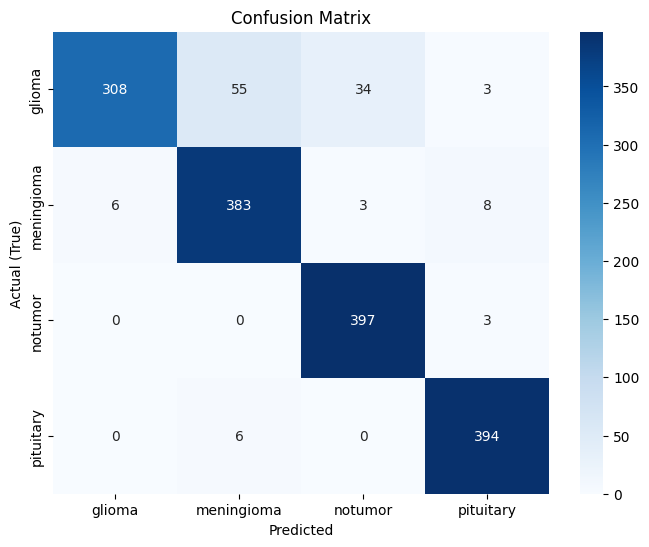

In [19]:
class_names = test_dataset.classes
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual (True)')
plt.title('Confusion Matrix')
plt.show()

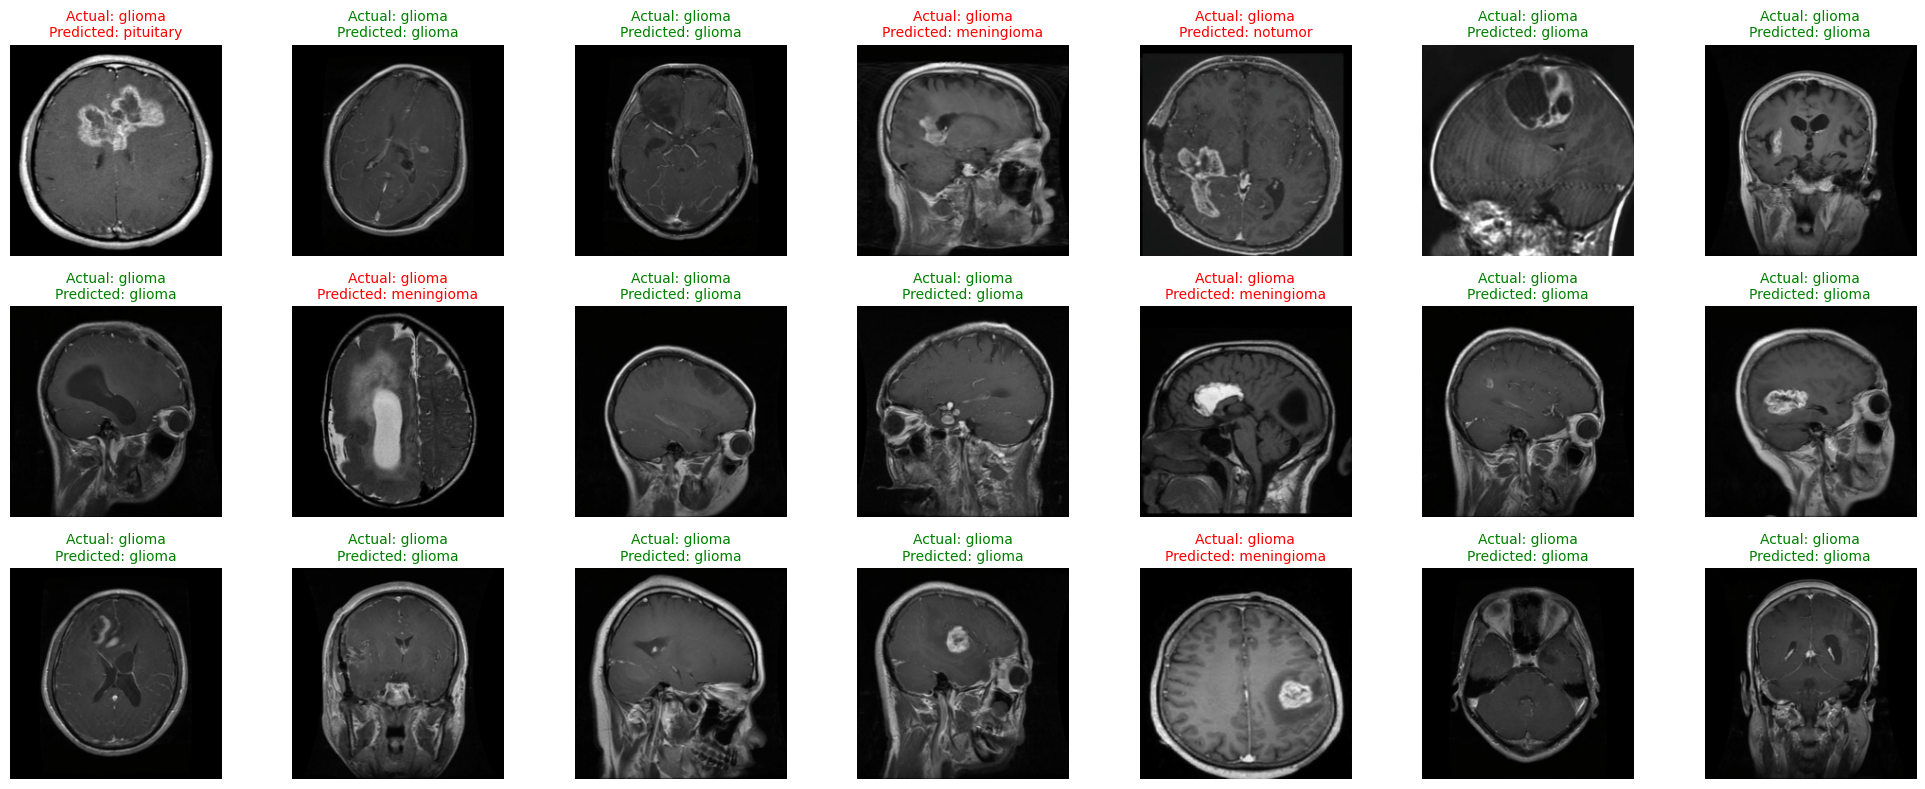

In [22]:
ROWS = 3
COLS = 7
NUM_IMAGES = ROWS * COLS

dataiter = iter(test_loader)
images, labels = next(dataiter)

images_gpu = images.to(device)
final_model.eval()
with torch.no_grad():
    outputs = final_model(images_gpu)
    _, preds = torch.max(outputs, 1)

class_names = test_dataset.classes

fig, axes = plt.subplots(nrows=ROWS, ncols=COLS, figsize=(20, 8))
index = 0

# เพิ่มค่า Mean/Std ให้ตรงกับตอนเทรนเป๊ะๆ
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(ROWS):
    for j in range(COLS):
        if index >= len(images): break

        ax = axes[i, j]

        # 1. แปลง Tensor -> Numpy
        img = images[index].permute(1, 2, 0).cpu().numpy()

        # 2. ✅ แก้ตรงนี้: Un-normalize (คูณ Std + บวก Mean กลับคืน)
        img = std * img + mean

        # 3. Clip ให้อยู่ในช่วง 0-1 (กันเหนียว) แล้วค่อยโชว์
        img = np.clip(img, 0, 1)

        # เตรียม Label
        true_label = class_names[labels[index].item()]
        pred_label = class_names[preds[index].item()]

        ax.imshow(img)

        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f'Actual: {true_label}\nPredicted: {pred_label}',
                     color=color, fontsize=10)

        ax.axis('off')
        index += 1

plt.tight_layout()
plt.show()

In [23]:
!pip install huggingface_hub

from huggingface_hub import notebook_login

# พอกดรัน มันจะมีช่องให้วาง Token ที่เรา Copy มาตะกี้ครับ
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [29]:
from huggingface_hub import HfApi

api = HfApi()

# 1. ตั้งชื่อ Username และชื่อ Model ของคุณ
username = "palmyz0" # ⚠️ แก้เป็นชื่อ Username HF ของคุณ
model_name = "brain-tumor-resnet50-finetune-with-optuna" # ตั้งชื่อโปรเจคเท่ๆ
repo_id = f"{username}/{model_name}"

# 2. สร้าง Repository บน HF
api.create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)
print(f"✅ สร้าง Repo สำเร็จ: https://huggingface.co/{repo_id}")

# 3. อัปโหลดไฟล์โมเดล (.pth)
print("🚀 กำลังอัปโหลดโมเดล... (อาจใช้เวลาหน่อยไฟล์มันใหญ่)")
api.upload_file(
    path_or_fileobj="final_best_brain_tumor_model.pth", # ⚠️ ชื่อไฟล์ใน Colab ของคุณ
    path_in_repo="model.pth",             # ชื่อไฟล์ที่จะไปโผล่บนเว็บ
    repo_id=repo_id,
    repo_type="model",
)


# สมมติคุณเซฟรูปกราฟไว้ชื่อ 'confusion_matrix.png'
api.upload_file(

    path_or_fileobj="confusion_matrix.png",
    path_in_repo="confusion_matrix.png",
    repo_id=repo_id,
    repo_type="model",
    )

print("🎉 อัปโหลดเสร็จสิ้น! ไปดูที่หน้าเว็บได้เลย")

✅ สร้าง Repo สำเร็จ: https://huggingface.co/palmyz0/brain-tumor-resnet50-finetune-with-optuna
🚀 กำลังอัปโหลดโมเดล... (อาจใช้เวลาหน่อยไฟล์มันใหญ่)


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...est_brain_tumor_model.pth:  17%|#6        | 16.7MB / 98.6MB            

No files have been modified since last commit. Skipping to prevent empty commit.


🎉 อัปโหลดเสร็จสิ้น! ไปดูที่หน้าเว็บได้เลย
